![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 1. Waveguides

Welcome to our Photonic Integrated Circuits Laboratory! Throughout the course, we will be using a Python package called [GDSFactory](https://gdsfactory.github.io/gdsfactory/index.html). This is an open-source tool, and is a great alternative to other commercial software like Synopsys Optodesigner, Luceda Photonics, or Lumerical/Interconnect. Since it runs on Python, you have two options for executing your laboratory tasks:

1. **Local installation on your own PC** (Recommended): Please note that we will not spend class time on installing the software. However, feel free to reach out if you need help with the installation.

2. **Cloud Workspace**: Alternatively, you can use a cloud-based solution if the Local installation does not work.

## 0. Imports

For this laboratory you will need the following libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength


In [2]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Effective index of a waveguide

### Convergence Tests
We have asumed until now, that the **real** value of the effective index for each cross-section is the value provided by this mode-solver. However, this number relies on a numerical method, making it sensible to some input parameters, such as the selected grid. The objective of this section is to find the dependence of the **calculated** value of the effective index with the *grid_resolution* and the *max_grid_scaling*, the two parameters that we can modify from the automatic grid function used at the gt.modes.Waveguide() function.  <br>
- Consider a 1.2 um width deep waveguide (SiNx), with 0.3 um height operating at 1550 nm.
    - Sweep the *grid_resolution* between 10 and 100 in steps of 10. Plot the **calculated** effective index vs the *grid_resolution*. 
    - Select a value for the *grid_resolution* from the latter sweep (where the calculated index remains almost constant), and sweep the *max_grid_scaling* from 1.2 to 1.6 in steps of 0.1. Plot the **calculated** effective index vs the *max_grid_scaling*.
    - Conclude which will be the best configuration for the grid parameters for this particular case. 

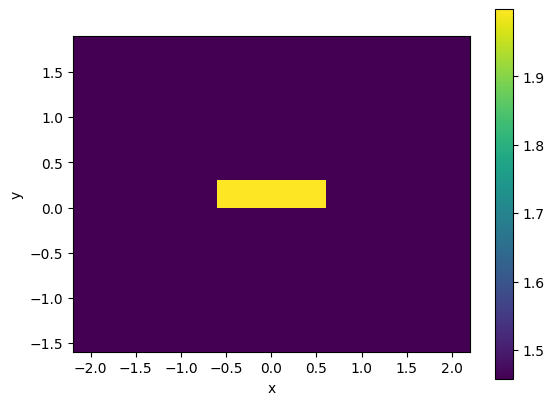

In [3]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid 
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()

# Student continue your code here ...



2026-03-04 10:38:10.697 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_09770a5eb4303d37.npz.
2026-03-04 10:38:10.728 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_972b4c36731994ce.npz.
2026-03-04 10:38:10.733 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4aa1037aeb7bae0f.npz.
2026-03-04 10:38:10.737 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4a7cfe924ea84b0e.npz.
2026-03-04 10:38:10.742 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a75f11ee34197d65.npz.
2026-03-04 10:38:10.746 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_9f3aaac580067da9.npz.
2026-03-04 10:38:10.750 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a122f2de27436370.npz.
2026-03-04 10:38:10.753 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_55052adad499f4e5.npz.


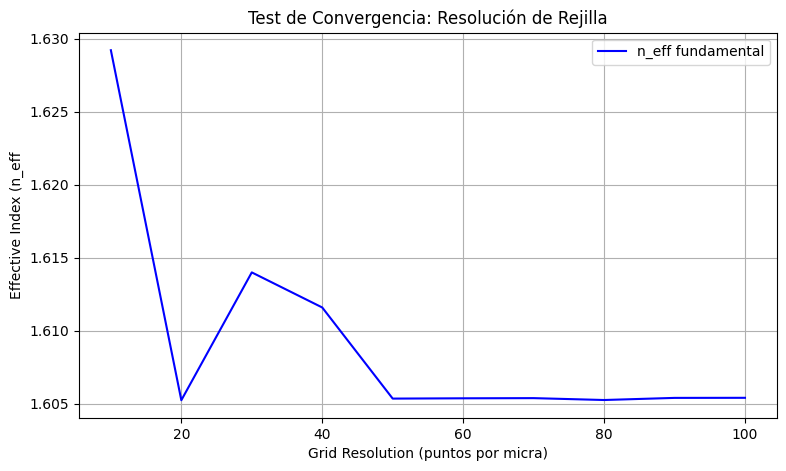

In [4]:
#BARRIDO DE GRID RESOLUTIONS
resolutions=np.arange(10,110,10)
neff_res= []

for res in resolutions: 
    deep_waveguide = gt.modes.Waveguide(
    core_width=1.2,
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    core_material='sin',
    clad_material='sio2',
    wavelength=1550 * nm,
    num_modes=1,
    max_grid_scaling=1.5,
    grid_resolution=res,
    cache_path='.cache/',
    precision='double'
)
    neff_res.append(deep_waveguide.n_eff.real)
    

plt.figure(figsize=(9, 5))
plt.plot(resolutions, neff_res, color='blue', label='n_eff fundamental')
plt.title('Test de Convergencia: Resolución de Rejilla')
plt.xlabel('Grid Resolution (puntos por micra)')
plt.ylabel('Effective Index (n_eff')
plt.grid(True)
plt.legend()
plt.show()


2026-03-04 10:38:10.910 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_17cb1fa5abd35339.npz.
2026-03-04 10:38:10.919 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_686338e809798827.npz.
2026-03-04 10:38:10.924 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_61b4bc857f53db0c.npz.
2026-03-04 10:38:10.930 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_972b4c36731994ce.npz.
2026-03-04 10:38:10.935 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4cb3fe425fdc2963.npz.


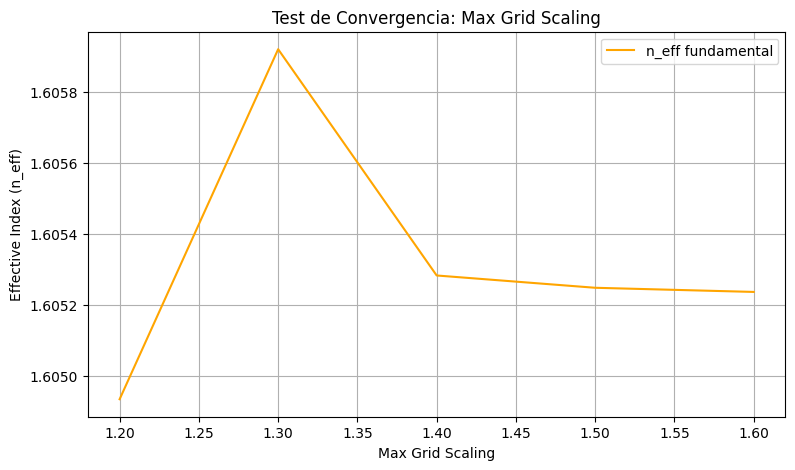

In [5]:

#BARRIDO DE MAX GRID RESOLUTIONS
scalings=np.linspace(1.2,1.6,5)
neff_scale= []
res_elegida= 20
for scale in scalings: 
    deep_waveguide = gt.modes.Waveguide(
    core_width=1.2,
    core_thickness=300 * nm, 
    slab_thickness=0 * nm, 
    core_material='sin', 
    clad_material='sio2', 
    wavelength=1550 * nm, 
    num_modes=1, 
    max_grid_scaling=scale,
    grid_resolution=res_elegida,
    cache_path='.cache/', 
    precision='double',
)
    neff_scale.append(deep_waveguide.n_eff.real)
    
plt.figure(figsize=(9, 5))
plt.plot(scalings, neff_scale, color='orange', label='n_eff fundamental')
plt.title('Test de Convergencia: Max Grid Scaling')
plt.xlabel('Max Grid Scaling')
plt.ylabel('Effective Index (n_eff)')
plt.grid(True)
plt.legend()
plt.show()


## LO.2. Width dependence

- Perform a sweep of the **deep** waveguide width. Use the code provided in the following cell or program your own sweep. 

  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-04 10:38:11.107 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b709aaddd3650849.npz.
2026-03-04 10:38:11.113 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5581ce122cc5e3a5.npz.
2026-03-04 10:38:11.118 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_19788afb20555fb2.npz.
2026-03-04 10:38:11.121 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7aafeeac46405a15.npz.
2026-03-04 10:38:11.124 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6374b7aa3461078b.npz.
2026-03-04 10:38:11.129 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3d7d22d1954b8509.npz.
2026-03-04 10:38:11.134 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bf7473bb4b227302.npz.
2026-03-04 10:38:11.138 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2bdf1aab784d3a25.npz.


  0%|          | 0/11 [00:00<?, ?it/s]

2026-03-04 10:38:11.189 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b709aaddd3650849.npz.
2026-03-04 10:38:11.200 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5581ce122cc5e3a5.npz.
2026-03-04 10:38:11.205 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_19788afb20555fb2.npz.
2026-03-04 10:38:11.216 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7aafeeac46405a15.npz.
2026-03-04 10:38:11.221 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_6374b7aa3461078b.npz.
2026-03-04 10:38:11.224 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3d7d22d1954b8509.npz.
2026-03-04 10:38:11.228 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_bf7473bb4b227302.npz.
2026-03-04 10:38:11.233 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2bdf1aab784d3a25.npz.


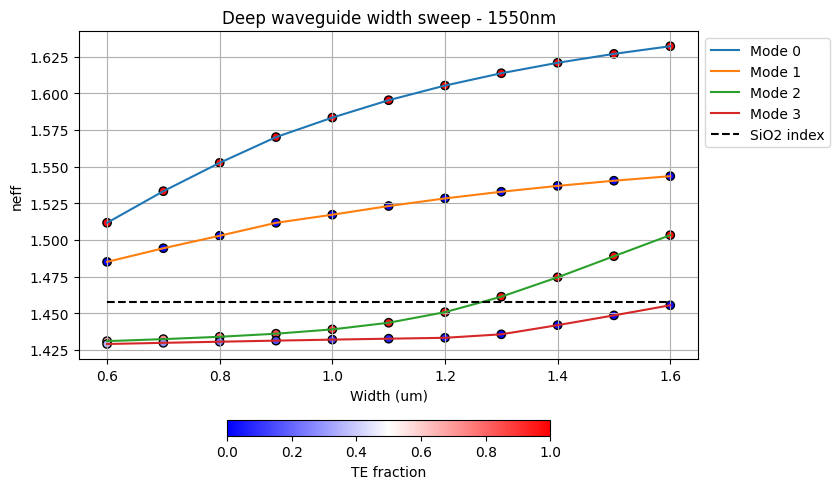

In [6]:
wavelength = 1550*nm # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.5,
    grid_resolution=20, 
)

w = np.linspace(0.6,1.6,11) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, core_width=w)
sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide, core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

## LO.3. Waveguide compact model

A compact model of an integrated photonic waveguide is a reduced-order mathematical model that describes the waveguide’s optical behavior—such as phase propagation, loss, and dispersion, using analytical or semi-analytical equations. Consider: 

Transfer function for propagation in a waveguide:

$$
H(\lambda)
= e^{-j\,\beta(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\beta(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\beta(\lambda)\}\,z}.
$$

Where 

$$
\beta(\lambda)
= \frac{2\pi}{\lambda}\,\mathrm{Re}\{n_\mathrm{eff}(\lambda)\}.
$$

Let's model the waveguide's effective index wavelength variation using a second order polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Where 

1. 
$$
n_\mathrm{eff}(\lambda_0) = n_1
$$
2. 
$$
n_g(\lambda_0) = n_1 - n_2\,\lambda_0
$$
3. 
$$
D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

- Find the **compact models** of the following waveguides: 
    - Deep waveguide, height = 300nm, width = 1.2um 
    - Shallow waveguide, core height = 300nm, slab height = 150 nm, width = 1.2um 

**TIP**. Use the Lab0.1.Modesolver results (neff vs lambda) as starting point. Fit the results using a second order polynomial (with the lambda_0 shift) and relate the fit results to n_g and D values.

2026-03-04 10:38:11.616 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e70065e5b5dc42c3.npz.
0.09735506571548527 -0.21617694948863667 1.6049166291026742
=== DEEP WAVEGUIDE: MODELO TE ===
neff(L0): 1.6049 | ng(L0): 1.9400 | D: -1006.70

=== DEEP WAVEGUIDE: MODELO TM ===
neff(L0): 1.5272 | ng(L0): 1.7720 | D: -1590.69


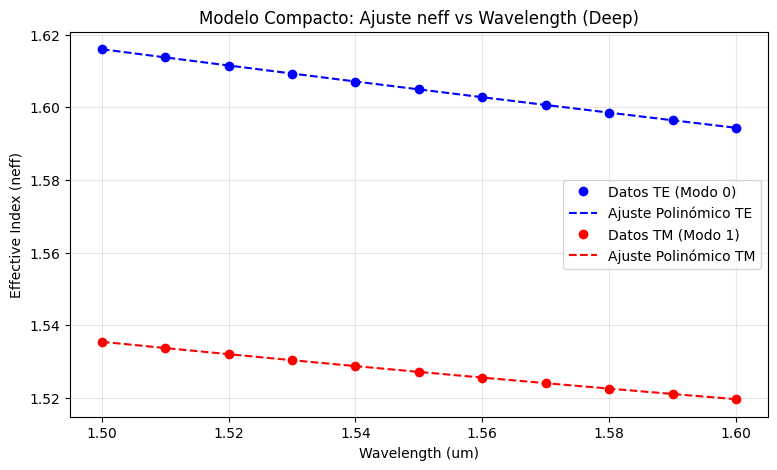

In [7]:
import numpy as np
import matplotlib.pyplot as plt

wavelengths = np.linspace(1.500, 1.600, 11)  
lambda0 = 1.55                               
c_speed = 299792458                          
delta_l = wavelengths - lambda0              # (L - L0)

deep_wg = gt.modes.Waveguide(
    wavelength=wavelengths, 
    core_width=1.2, 
    slab_thickness=0.0, 
    core_material='sin', 
    clad_material='sio2', 
    core_thickness=300 * nm,
    num_modes=4, 
    grid_resolution=20, 
    cache_path='.cache/'
)

res_neff = deep_wg.n_eff.real 


#Modelo Compacto - MODO TE (Fundamental)
neff_TE = res_neff[:, 0]

#Ajuste polinómico de grado 2
n3_TE, n2_TE, n1_TE = np.polyfit(delta_l, neff_TE, 2)
print(n3_TE, n2_TE, n1_TE)

n1_concl_TE = n1_TE                                    
ng_concl_TE = n1_TE - n2_TE * lambda0                     
D_concl_TE  = -(2 * (lambda0 * 1e-6) * (n3_TE * 1e12)) / c_speed # D


# Modelo Compacto - MODO TM
neff_TM = res_neff[:, 1]

n3_TM, n2_TM, n1_TM = np.polyfit(delta_l, neff_TM, 2)

n1_concl_TM = n1_TM
ng_concl_TM = n1_TM - n2_TM * lambda0
D_concl_TM  = -(2 * (lambda0 * 1e-6) * (n3_TM * 1e12)) / c_speed


# Resultados y Gráfica

print("=== DEEP WAVEGUIDE: MODELO TE ===")
print(f"neff(L0): {n1_concl_TE:.4f} | ng(L0): {ng_concl_TE:.4f} | D: {D_concl_TE*1e6:.2f}")

print("\n=== DEEP WAVEGUIDE: MODELO TM ===")
print(f"neff(L0): {n1_concl_TM:.4f} | ng(L0): {ng_concl_TM:.4f} | D: {D_concl_TM*1e6:.2f}")


plt.figure(figsize=(9, 5))

# Modo TE: Puntos originales y curva ajustada
plt.plot(wavelengths, neff_TE, 'ob', label='Datos TE (Modo 0)')
plt.plot(wavelengths, n1_TE + n2_TE*delta_l + n3_TE*delta_l**2, '--b', label='Ajuste Polinómico TE')

# Modo TM: Puntos originales y curva ajustada
plt.plot(wavelengths, neff_TM, 'or', label='Datos TM (Modo 1)')
plt.plot(wavelengths, n1_TM + n2_TM*delta_l + n3_TM*delta_l**2, '--r', label='Ajuste Polinómico TM')

plt.title("Modelo Compacto: Ajuste neff vs Wavelength (Deep)")
plt.xlabel("Wavelength (um)")
plt.ylabel("Effective Index (neff)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

2026-03-04 10:38:11.854 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_622183ae5d2fe13f.npz.


=== SHALLOW WAVEGUIDE: MODELO TE ===
neff(L0): 1.6241 | ng(L0): 1.9158 | D: -989.54

=== SHALLOW WAVEGUIDE: MODELO TM ===
neff(L0): 1.5419 | ng(L0): 1.7474 | D: -1530.51


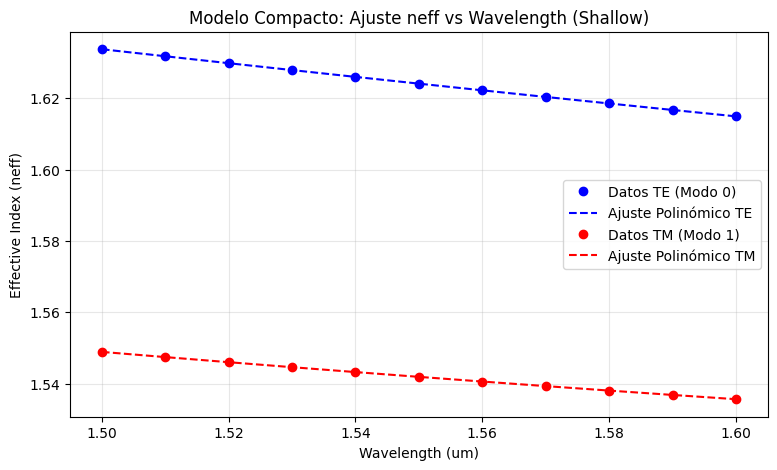

In [8]:

wavelengths = np.linspace(1.500, 1.600, 11)  
lambda0 = 1.55                               
c_speed = 299792458                          
delta_l = wavelengths - lambda0           

shallow_wg = gt.modes.Waveguide(
    wavelength=wavelengths, 
    core_width=1.2, 
    slab_thickness=150 * nm, 
    core_material='sin', 
    clad_material='sio2', 
    core_thickness=300 * nm,
    num_modes=2, 
    grid_resolution=20, 
    cache_path='.cache/'
)

res_neff = shallow_wg.n_eff.real 


#Modelo Compacto - MODO TE (Fundamental)
neff_TE = res_neff[:, 0]

n3_TE, n2_TE, n1_TE = np.polyfit(delta_l, neff_TE, 2)

n1_concl_TE = n1_TE                                     
ng_concl_TE = n1_TE - n2_TE * lambda0                 
D_concl_TE  = -(2 * (lambda0 * 1e-6) * (n3_TE * 1e12)) / c_speed # D

#Modelo Compacto - MODO TM
neff_TM = res_neff[:, 1]

n3_TM, n2_TM, n1_TM = np.polyfit(delta_l, neff_TM, 2)

n1_concl_TM = n1_TM
ng_concl_TM = n1_TM - n2_TM * lambda0
D_concl_TM  = -(2 * (lambda0 * 1e-6) * (n3_TM * 1e12)) / c_speed


# Resultados y Gráfica
print("=== SHALLOW WAVEGUIDE: MODELO TE ===")
print(f"neff(L0): {n1_concl_TE:.4f} | ng(L0): {ng_concl_TE:.4f} | D: {D_concl_TE*1e6:.2f}")

print("\n=== SHALLOW WAVEGUIDE: MODELO TM ===")
print(f"neff(L0): {n1_concl_TM:.4f} | ng(L0): {ng_concl_TM:.4f} | D: {D_concl_TM*1e6:.2f}")

# Gráfica de validación
plt.figure(figsize=(9, 5))

# Modo TE: Puntos originales y curva ajustada
plt.plot(wavelengths, neff_TE, 'ob', label='Datos TE (Modo 0)')
plt.plot(wavelengths, n1_TE + n2_TE*delta_l + n3_TE*delta_l**2, '--b', label='Ajuste Polinómico TE')

# Modo TM: Puntos originales y curva ajustada
plt.plot(wavelengths, neff_TM, 'or', label='Datos TM (Modo 1)')
plt.plot(wavelengths, n1_TM + n2_TM*delta_l + n3_TM*delta_l**2, '--r', label='Ajuste Polinómico TM')

plt.title("Modelo Compacto: Ajuste neff vs Wavelength (Shallow)")
plt.xlabel("Wavelength (um)")
plt.ylabel("Effective Index (neff)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## LO.4. Bend waveguide radius vs. loss – deep

The bend loss has three primary contributions:

1. Mode-mismatch loss
2. Radiation loss
3. Propagation loss

2026-03-04 10:38:12.071 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1592dba1d8e935a8.npz.


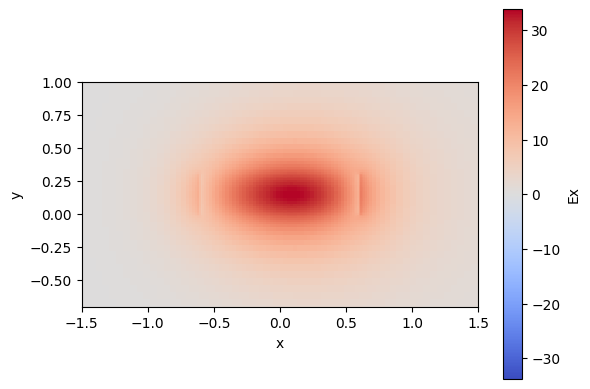

In [9]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=20, # Bend radius
)

bend_1550.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='real', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 

### Mode-mismatch loss

Bend waveguide mode differs slightly from the straight waveguide mode, wich yield into mode-convertion losses. We can calculate this factor with as the overlap of the latter two modes. 

This is already implemented on GDSfactory library: 

  0%|          | 0/10 [00:00<?, ?it/s]

/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

Text(0, 0.5, 'Mismatch (dB)')

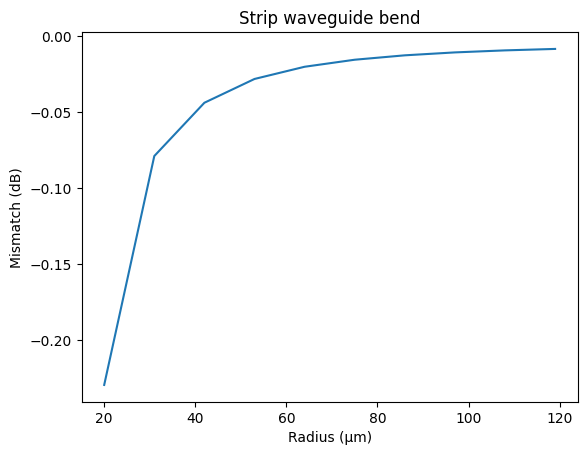

In [10]:
radii = np.arange(20.0, 120,11)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

plt.plot(radii, 10 * np.log10(mismatch))
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")

#Calcular modo guia curvada y calcular integral de solape de cada una para sacar la potencia

In [11]:
#COMENTARIOS GRAFICA
#haciendo variaciones, en 20 micras tendriamos perdidas menores a -0.2dB, En cada transicion de 
#recta a curva tendremos por cada cuarto de curva tenemos 2 vces la de la guia recta. 
#para curavturas grandes no hay casi perdidas pero cuando se disminuye el radio aumenta el factor de perdidas.
#el mejor radio seria si no quieres tantas perididas es mejor coger un radio grande
#Pero como radio seguro es el que se empieza a suavizar, es decir, r=[40,50]um


### Propagation loss

Consider the equivalent linear length of the quarter-circle bend. Light will attenuate following a trend quantified with the experimentally measured parameter $$\alpha [\mathrm{dB}/\mathrm{cm}]$$. It depends on the fabrication process mainly. We will add this loss (in dBs) to the mode-mismatch loss to calculate the total loss per bend. 

*We are not considering the radiation losses, mainly because is not easy to implement a quick simulation for this parameter. Under certain conditions, the main loss sources are the ones considered in this example


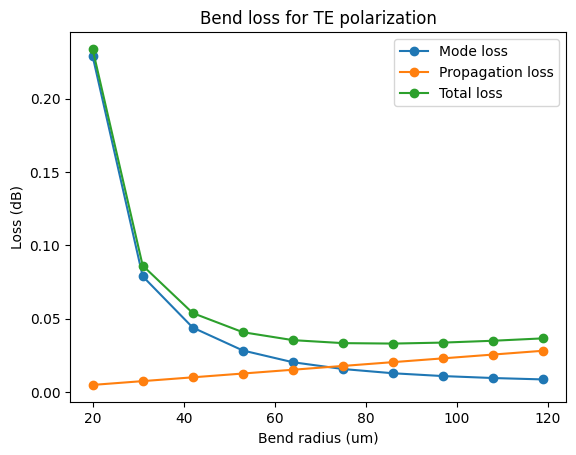

In [12]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss

plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), "-o", label="Mode loss")
plt.plot(radii, propagation_loss, "-o", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), "-o", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

In [13]:
#los putos naranjas es lineal (loss=0.5*pi*r*alpha) donde la pendiente son las perdidas
#la peridida total=azul+naranja
#una zona segura seria entorno a 75-100um porque se mantiene mas cte.
#Al aumentar el radio disminuye la peridida modal(azul) pero aumenta la perdida de propagacion porque aumenta el recorrido (naranja)

- Use the code provided in this section to calculate the safe radius for 1.2 um width deep waveguides at 1.5 um. 

Cálculo de neff para guías curvas (Width = 1.0 um):
2026-03-04 10:39:07.090 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1fae764bf0767424.npz.
R=25 um | neff_TE0: 1.5936967347472588 | neff_TM0: 1.5616709718527775
2026-03-04 10:39:07.099 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b9bdbd79392dcce5.npz.
R=50 um | neff_TE0: 1.5923730864096373 | neff_TM0: 1.5195170831468787
2026-03-04 10:39:07.107 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_08a772776e70889d.npz.
R=75 um | neff_TE0: 1.592190009301662 | neff_TM0: 1.5184577326476207
2026-03-04 10:39:07.116 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_779c02d389de4a38.npz.
R=100 um | neff_TE0: 1.5921419483291859 | neff_TM0: 1.5180899022608325
2026-03-04 10:39:07.123 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2ff7e8d79f403ed2.npz.
R=125 um | neff_TE0: 1.5921268271485498 | n

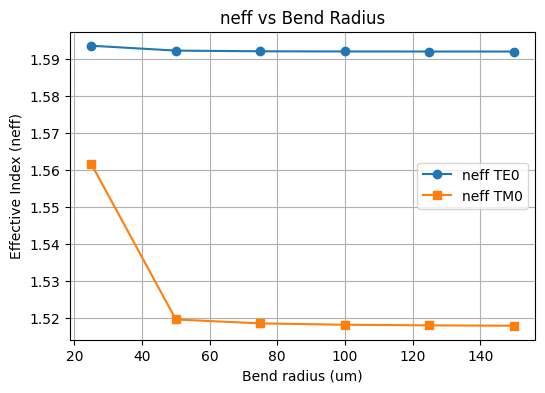

In [14]:
radios = [25, 50, 75, 100, 125, 150]
neff_TE = []
neff_TM = []

print("Cálculo de neff para guías curvas (Width = 1.0 um):")

for r in radios:
    bend_mode = gt.modes.Waveguide(
        wavelength=1550 * nm, 
        core_width=1.0,        
        slab_thickness=0.0,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300 * nm,
        num_modes=2,        
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=30, 
        bend_radius=r  
    )
    
    n_te = np.real(bend_mode.n_eff[0])
    n_tm = np.real(bend_mode.n_eff[1])
    
    neff_TE.append(n_te)
    neff_TM.append(n_tm)
    
    print(f"R={r} um | neff_TE0: {n_te} | neff_TM0: {n_tm}")

# neff vs R 
plt.figure(figsize=(6,4))
plt.plot(radios, neff_TE, 'o-', label='neff TE0')
plt.plot(radios, neff_TM, 's-', label='neff TM0')
plt.xlabel("Bend radius (um)")
plt.ylabel("Effective Index (neff)")
plt.title("neff vs Bend Radius")
plt.legend()
plt.grid(True)
plt.show()

  0%|          | 0/6 [00:00<?, ?it/s]

/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

Resultados para Width = 1.0 um a 1.55 um:
R=25 um | Mismatch: 0.1214214049636583 dB | Prop: 0.005890486225480863 dB | TOTAL: 0.12731189118913916 dB/90º
R=50 um | Mismatch: 0.0268858320684867 dB | Prop: 0.011780972450961725 dB | TOTAL: 0.03866680451944843 dB/90º
R=75 um | Mismatch: 0.013059585432477362 dB | Prop: 0.017671458676442587 dB | TOTAL: 0.03073104410891995 dB/90º
R=100 um | Mismatch: 0.00844151824753799 dB | Prop: 0.02356194490192345 dB | TOTAL: 0.03200346314946144 dB/90º
R=125 um | Mismatch: 0.006374208556564468 dB | Prop: 0.02945243112740431 dB | TOTAL: 0.03582663968396878 dB/90º
R=150 um | Mismatch: 0.0052845032268012205 dB | Prop: 0.035342917352885174 dB | TOTAL: 0.040627420579686394 dB/90º


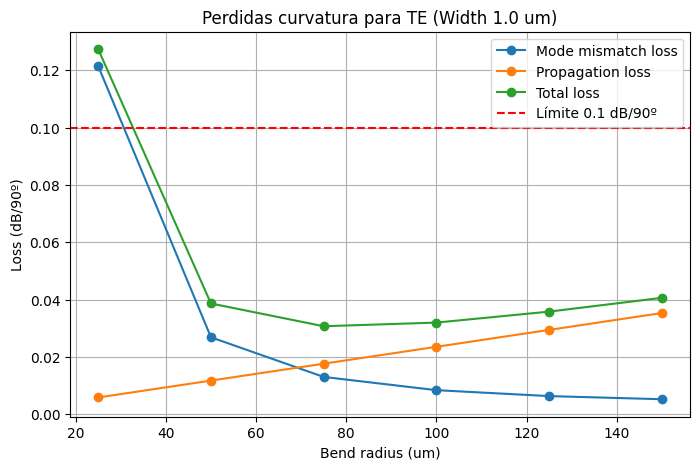

In [15]:

radios = np.array([25,50,75,100,125,150])

# Guía de onda par TE
bend_te = gt.modes.Waveguide(
    wavelength=1550 * nm, 
    core_width=1.0,       
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
)

# Mismatch Loss
mismatch_loss = gt.modes.sweep_bend_mismatch(bend_te, radios)
mismatch_loss_dB = -10 * np.log10(mismatch_loss) 

# Propagation Loss
dB_cm = 1.5 
length_cm = 0.5 * np.pi * radios * 1e-4
prop_loss_dB = dB_cm * length_cm

# Pérdida Total
total_loss_dB = mismatch_loss_dB + prop_loss_dB

# Imprimir resultados para ver cuál es menor a 0.1 dB/90
print("Resultados para Width = 1.0 um a 1.55 um:")
for i in range(len(radios)):
    r = radios[i]
    m_loss = mismatch_loss_dB[i]
    p_loss = prop_loss_dB[i]
    t_loss = total_loss_dB[i]
    
    print(f"R={r} um | Mismatch: {m_loss} dB | Prop: {p_loss} dB | TOTAL: {t_loss} dB/90º")

# Graficar para pegar en la diapo
plt.figure(figsize=(8,5))
plt.title("Perdidas curvatura para TE (Width 1.0 um)")
plt.plot(radios, mismatch_loss_dB, "o-", label="Mode mismatch loss")
plt.plot(radios, prop_loss_dB, "o-", label="Propagation loss")
plt.plot(radios, total_loss_dB, "o-", label="Total loss")
plt.axhline(y=0.1, color='r', linestyle='--', label="Límite 0.1 dB/90º")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB/90º)")
plt.legend()
plt.grid(True)
plt.show()

  0%|          | 0/6 [00:00<?, ?it/s]

/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

10:39:54 CET WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

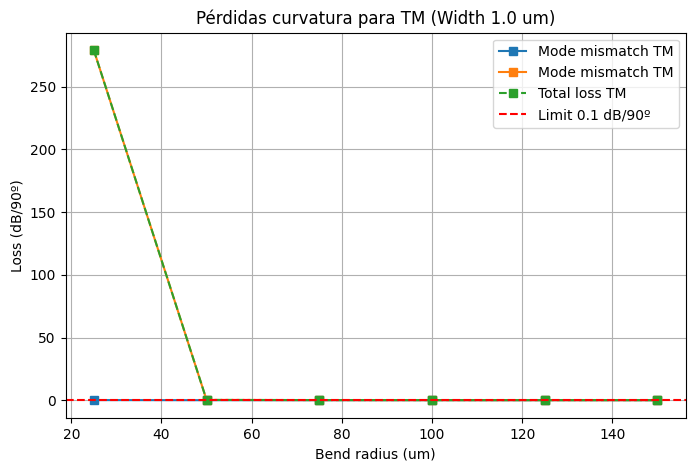

In [16]:
radios = np.array([25, 50, 75, 100, 125, 150])

bend_tm = gt.modes.Waveguide(
    wavelength=1550 * nm, 
    core_width=1.0,       
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=2,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
)

mismatch_TM = gt.modes.sweep_bend_mismatch(bend_tm, radios)
mismatch_TM_dB = -10 * np.log10(mismatch_TM)

dB_cm = 1.5
length_cm = 0.5 * np.pi * radios * 1e-4
prop_loss_dB = dB_cm * length_cm

total_loss_TM = mismatch_TM_dB[:, 1] + prop_loss_dB

plt.figure(figsize=(8,5))
plt.title("Pérdidas curvatura para TM (Width 1.0 um)")
plt.plot(radios, mismatch_TM_dB, "s-", label="Mode mismatch TM")
plt.plot(radios, total_loss_TM, "s--", label="Total loss TM")
plt.axhline(y=0.1, color='r', linestyle='--', label="Limit 0.1 dB/90º")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB/90º)")
plt.legend()
plt.grid(True)
plt.show()

## EXTRA

All the past simulations were done considering as core material de Silicon Nitride (SiNx) and Silicon Dioxide (SiO2) as cladding material. Now, **simulate the Silicon-On-Insulator technology changing the core material to Silicon (Si)**. In this case, the dimensions will be 220 nm heigth and 500 nm width. 
1. Repeat the LO.1. wavelength behavior simulations, considering the updated materials and dimensions. 
2. Repeat the LO.2. width dependence analysis, now sweeping in a 300nm - 1um range. 
3. Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range. 
4. **Compare the SiNx and SOI technologies** 

2026-03-04 10:40:17.451 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4a1d722b79a898fe.npz.
2026-03-04 10:40:17.458 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_03f4f47742c6dd39.npz.
2026-03-04 10:40:17.463 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_df6b8c7ded5c819f.npz.
2026-03-04 10:40:17.469 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e180c41701f0a45c.npz.
2026-03-04 10:40:17.472 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_99c2a1f132c5aa29.npz.
2026-03-04 10:40:17.477 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_376ad1e6757d68e9.npz.
2026-03-04 10:40:17.482 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d39692b947d95237.npz.
2026-03-04 10:40:17.487 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_778e926092e76bcf.npz.


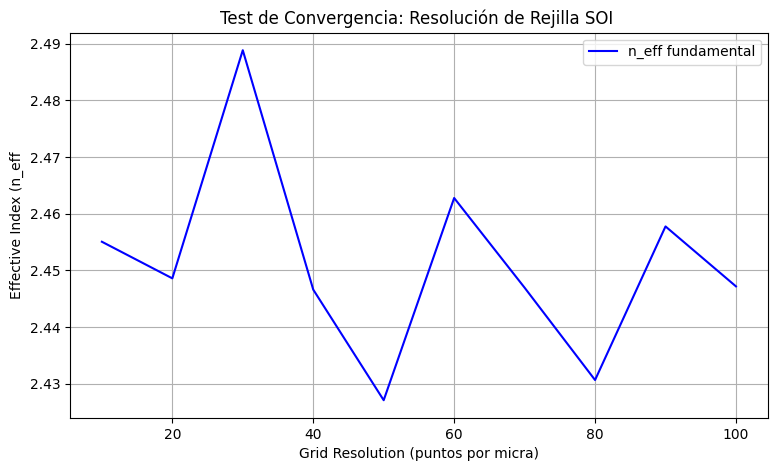

In [17]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=0.5, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid 
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)


#BARRIDO DE GRID RESOLUTIONS
resolutions=np.arange(10,110,10)
neff_res= []

for res in resolutions: 
    deep_waveguide = gt.modes.Waveguide(
    core_width=0.5,
    core_thickness=220 * nm,
    slab_thickness=0 * nm,
    core_material='si',
    clad_material='sio2',
    wavelength=1550 * nm,
    num_modes=1,
    max_grid_scaling=1.5,
    grid_resolution=res,
    cache_path='.cache/',
    precision='double'
)
    neff_res.append(deep_waveguide.n_eff.real)
    

plt.figure(figsize=(9, 5))
plt.plot(resolutions, neff_res, color='blue', label='n_eff fundamental')
plt.title('Test de Convergencia: Resolución de Rejilla SOI ')
plt.xlabel('Grid Resolution (puntos por micra)')
plt.ylabel('Effective Index (n_eff')
plt.grid(True)
plt.legend()
plt.show()


2026-03-04 10:40:17.640 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cc4fc10128af5cd3.npz.
2026-03-04 10:40:17.646 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0dde524baa930045.npz.
2026-03-04 10:40:17.650 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f1e069993e9b7864.npz.
2026-03-04 10:40:17.654 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_03f4f47742c6dd39.npz.
2026-03-04 10:40:17.659 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e6ce3eac15aa54b7.npz.


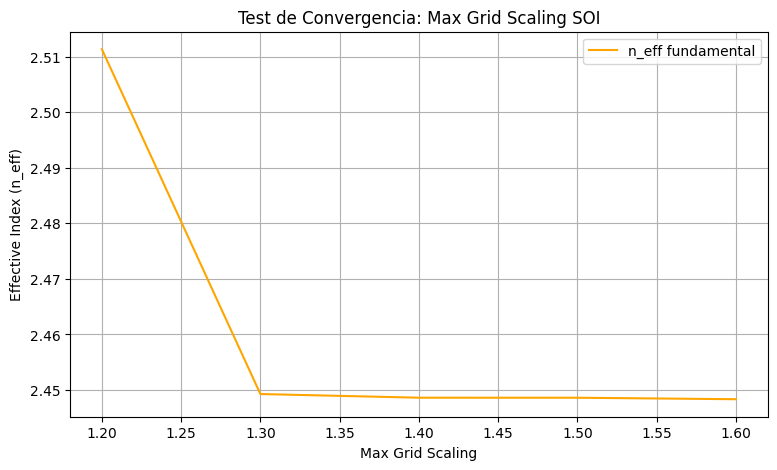

In [18]:

#BARRIDO DE MAX GRID RESOLUTIONS
scalings=np.linspace(1.2,1.6,5)
neff_scale= []
res_elegida= 20
for scale in scalings: 
    deep_waveguide = gt.modes.Waveguide(
    core_width=0.5,
    core_thickness=220 * nm, 
    slab_thickness=0 * nm, 
    core_material='si', 
    clad_material='sio2', 
    wavelength=1550 * nm, 
    num_modes=1, 
    max_grid_scaling=scale,
    grid_resolution=res_elegida,
    cache_path='.cache/', 
    precision='double',
)
    neff_scale.append(deep_waveguide.n_eff.real)
    
plt.figure(figsize=(9, 5))
plt.plot(scalings, neff_scale, color='orange', label='n_eff fundamental')
plt.title('Test de Convergencia: Max Grid Scaling SOI')
plt.xlabel('Max Grid Scaling')
plt.ylabel('Effective Index (n_eff)')
plt.grid(True)
plt.legend()
plt.show()


  0%|          | 0/8 [00:00<?, ?it/s]

/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

10:54:34 CET WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-03-04 10:54:34.732 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_23965c2eb87510b5.npz.


...

2026-03-04 10:55:31.589 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_a54bdce45581adf1.npz.


/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

2026-03-04 10:55:38.626 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ab32a33917b5a9f6.npz.


  0%|          | 0/8 [00:00<?, ?it/s]

2026-03-04 10:55:38.661 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_23965c2eb87510b5.npz.
2026-03-04 10:55:38.670 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_43f15da7d1b7ad6d.npz.
2026-03-04 10:55:38.677 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_911976577bac1427.npz.
2026-03-04 10:55:38.680 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b9486f94eee53576.npz.
2026-03-04 10:55:38.684 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8c41b90bbce5aeef.npz.
2026-03-04 10:55:38.691 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d8fbdea46b796878.npz.
2026-03-04 10:55:38.697 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a54bdce45581adf1.npz.
2026-03-04 10:55:38.702 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ab32a33917b5a9f6.npz.


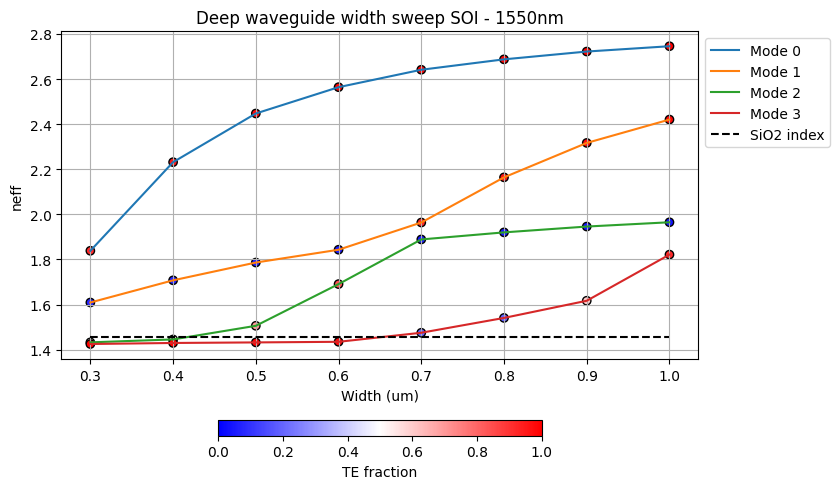

In [28]:
wavelength = 1550*nm # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=0.5,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.3,
    grid_resolution=50, 
)

w = np.linspace(0.3,1,8) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, core_width=w)
sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide, core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep SOI - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

2026-03-04 10:40:18.350 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_38091c594b211d32.npz.
-0.03531502833806699 -1.1171255702427263 2.4498719049619626
=== DEEP WAVEGUIDE SOI: MODELO TE ===
neff(L0): 2.4499 | ng(L0): 4.1814 | D: 365.17

=== DEEP WAVEGUIDE SOI: MODELO TM ===
neff(L0): 1.7884 | ng(L0): 3.7318 | D: -18286.34


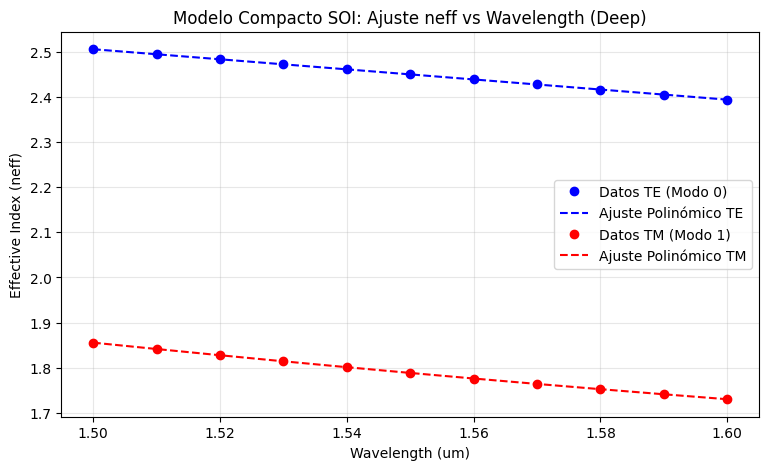

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

wavelengths = np.linspace(1.500, 1.600, 11)  
lambda0 = 1.55                               
c_speed = 299792458                          
delta_l = wavelengths - lambda0              # (L - L0)

deep_wg = gt.modes.Waveguide(
    wavelength=wavelengths, 
    core_width=0.5, 
    slab_thickness=0.0, 
    core_material='si', 
    clad_material='sio2', 
    core_thickness=220 * nm,
    num_modes=4, 
    grid_resolution=50, 
    cache_path='.cache/'
)

res_neff = deep_wg.n_eff.real 


#Modelo Compacto - MODO TE (Fundamental)
neff_TE = res_neff[:, 0]

#Ajuste polinómico de grado 2
n3_TE, n2_TE, n1_TE = np.polyfit(delta_l, neff_TE, 2)
print(n3_TE, n2_TE, n1_TE)

n1_concl_TE = n1_TE                                    
ng_concl_TE = n1_TE - n2_TE * lambda0                     
D_concl_TE  = -(2 * (lambda0 * 1e-6) * (n3_TE * 1e12)) / c_speed # D


# Modelo Compacto - MODO TM
neff_TM = res_neff[:, 1]

n3_TM, n2_TM, n1_TM = np.polyfit(delta_l, neff_TM, 2)

n1_concl_TM = n1_TM
ng_concl_TM = n1_TM - n2_TM * lambda0
D_concl_TM  = -(2 * (lambda0 * 1e-6) * (n3_TM * 1e12)) / c_speed


# Resultados y Gráfica

print("=== DEEP WAVEGUIDE SOI: MODELO TE ===")
print(f"neff(L0): {n1_concl_TE:.4f} | ng(L0): {ng_concl_TE:.4f} | D: {D_concl_TE*1e6:.2f}")

print("\n=== DEEP WAVEGUIDE SOI: MODELO TM ===")
print(f"neff(L0): {n1_concl_TM:.4f} | ng(L0): {ng_concl_TM:.4f} | D: {D_concl_TM*1e6:.2f}")


plt.figure(figsize=(9, 5))

# Modo TE: Puntos originales y curva ajustada
plt.plot(wavelengths, neff_TE, 'ob', label='Datos TE (Modo 0)')
plt.plot(wavelengths, n1_TE + n2_TE*delta_l + n3_TE*delta_l**2, '--b', label='Ajuste Polinómico TE')

# Modo TM: Puntos originales y curva ajustada
plt.plot(wavelengths, neff_TM, 'or', label='Datos TM (Modo 1)')
plt.plot(wavelengths, n1_TM + n2_TM*delta_l + n3_TM*delta_l**2, '--r', label='Ajuste Polinómico TM')

plt.title("Modelo Compacto SOI: Ajuste neff vs Wavelength (Deep)")
plt.xlabel("Wavelength (um)")
plt.ylabel("Effective Index (neff)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

2026-03-04 10:40:18.773 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7a2e6d8c91954e46.npz.
=== SHALLOW WAVEGUIDE SOI: MODELO TE ===
neff(L0): 2.6659 | ng(L0): 3.7608 | D: -1868.69

=== SHALLOW WAVEGUIDE SOI: MODELO TM ===
neff(L0): 2.4980 | ng(L0): 3.4985 | D: -2557.62


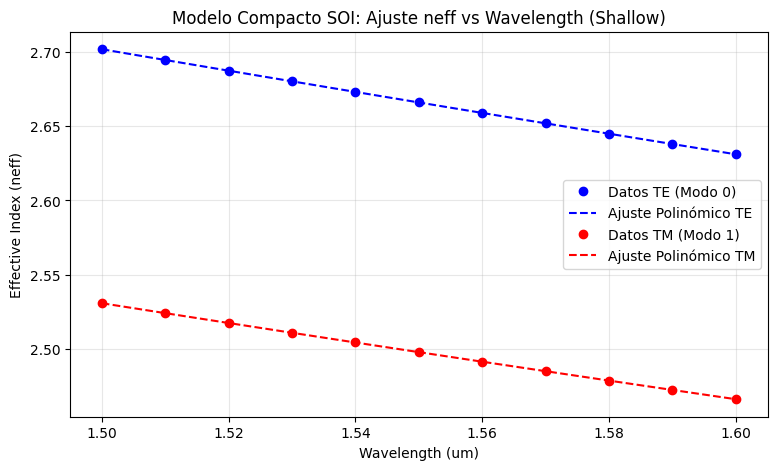

In [ ]:

wavelengths = np.linspace(1.500, 1.600, 11)  
lambda0 = 1.55                               
c_speed = 299792458                          
delta_l = wavelengths - lambda0           

shallow_wg = gt.modes.Waveguide(
    wavelength=wavelengths, 
    core_width=0.5, 
    slab_thickness=150 * nm, 
    core_material='si', 
    clad_material='sio2', 
    core_thickness=220 * nm,
    num_modes=2, 
    grid_resolution=50, 
    cache_path='.cache/'
)

res_neff = shallow_wg.n_eff.real 


#Modelo Compacto - MODO TE (Fundamental)
neff_TE = res_neff[:, 0]

n3_TE, n2_TE, n1_TE = np.polyfit(delta_l, neff_TE, 2)

n1_concl_TE = n1_TE                                     
ng_concl_TE = n1_TE - n2_TE * lambda0                 
D_concl_TE  = -(2 * (lambda0 * 1e-6) * (n3_TE * 1e12)) / c_speed # D

#Modelo Compacto - MODO TM
neff_TM = res_neff[:, 1]

n3_TM, n2_TM, n1_TM = np.polyfit(delta_l, neff_TM, 2)

n1_concl_TM = n1_TM
ng_concl_TM = n1_TM - n2_TM * lambda0
D_concl_TM  = -(2 * (lambda0 * 1e-6) * (n3_TM * 1e12)) / c_speed


# Resultados y Gráfica
print("=== SHALLOW WAVEGUIDE SOI: MODELO TE ===")
print(f"neff(L0): {n1_concl_TE:.4f} | ng(L0): {ng_concl_TE:.4f} | D: {D_concl_TE*1e6:.2f}")

print("\n=== SHALLOW WAVEGUIDE SOI: MODELO TM ===")
print(f"neff(L0): {n1_concl_TM:.4f} | ng(L0): {ng_concl_TM:.4f} | D: {D_concl_TM*1e6:.2f}")

# Gráfica de validación
plt.figure(figsize=(9, 5))

# Modo TE: Puntos originales y curva ajustada
plt.plot(wavelengths, neff_TE, 'ob', label='Datos TE (Modo 0)')
plt.plot(wavelengths, n1_TE + n2_TE*delta_l + n3_TE*delta_l**2, '--b', label='Ajuste Polinómico TE')

# Modo TM: Puntos originales y curva ajustada
plt.plot(wavelengths, neff_TM, 'or', label='Datos TM (Modo 1)')
plt.plot(wavelengths, n1_TM + n2_TM*delta_l + n3_TM*delta_l**2, '--r', label='Ajuste Polinómico TM')

plt.title("Modelo Compacto SOI: Ajuste neff vs Wavelength (Shallow)")
plt.xlabel("Wavelength (um)")
plt.ylabel("Effective Index (neff)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Cálculo de neff para guías curvas (Width = 0.5 um):


/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

11:03:14 CET WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

2026-03-04 11:03:14.757 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_e5b8dfdd55fadae6.npz.
R=5 um | neff_TE0: 2.4535655325419676 | neff_TM0: 1.9744822792059038


/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

...

2026-03-04 11:03:27.306 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_1519d8f9386d4496.npz.
R=15 um | neff_TE0: 2.4531881852279724 | neff_TM0: 1.7890882701977158


/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

2026-03-04 11:03:33.352 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_a7f9ba355fb83657.npz.
R=20 um | neff_TE0: 2.4532339975093516 | neff_TM0: 1.7886288404425326
2026-03-04 11:03:33.365 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4f9ccdab3d26e38f.npz.
R=25 um | neff_TE0: 2.4532713072020815 | neff_TM0: 1.7884058914251837


/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

2026-03-04 11:03:39.344 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_5fc1f3d9c4efbed0.npz.
R=30 um | neff_TE0: 2.4533002712544216 | neff_TM0: 1.7882789346669739


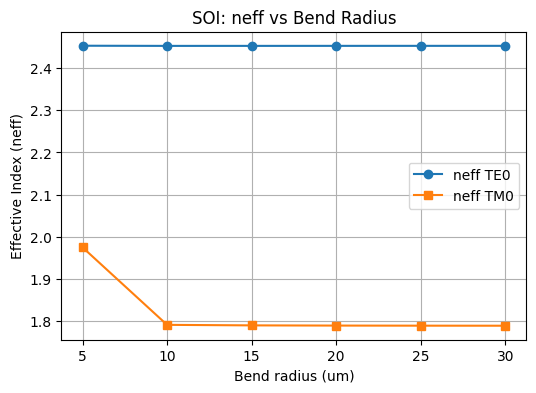

In [29]:

radios = [5, 10, 15, 20, 25, 30]
neff_TE = []
neff_TM = []

print("Cálculo de neff para guías curvas (Width = 0.5 um):")

for r in radios:
    bend_mode = gt.modes.Waveguide(
        wavelength=1550 * nm, 
        core_width=0.5,        
        slab_thickness=0.0,
        core_material='si',
        clad_material='sio2',
        core_thickness=220 * nm,
        num_modes=2,        
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.3,
        grid_resolution=50, 
        bend_radius=r  
    )
    
    n_te = np.real(bend_mode.n_eff[0])
    n_tm = np.real(bend_mode.n_eff[1])
    
    neff_TE.append(n_te)
    neff_TM.append(n_tm)
    
    print(f"R={r} um | neff_TE0: {n_te} | neff_TM0: {n_tm}")

# neff vs R 
plt.figure(figsize=(6,4))
plt.plot(radios, neff_TE, 'o-', label='neff TE0')
plt.plot(radios, neff_TM, 's-', label='neff TM0')
plt.xlabel("Bend radius (um)")
plt.ylabel("Effective Index (neff)")
plt.title("SOI: neff vs Bend Radius")
plt.legend()
plt.grid(True)
plt.show()

  0%|          | 0/6 [00:00<?, ?it/s]

/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

SOI Resultados para Width = 1.0 um a 1.55 um:
R=5 um | Mismatch: 0.009776973235917521 dB | Prop: 0.0011780972450961724 dB | TOTAL: 0.010955070481013693 dB/90º
R=10 um | Mismatch: 0.002537324411797674 dB | Prop: 0.002356194490192345 dB | TOTAL: 0.004893518901990019 dB/90º
R=15 um | Mismatch: 0.0015337744023260825 dB | Prop: 0.0035342917352885173 dB | TOTAL: 0.0050680661376146 dB/90º
R=20 um | Mismatch: 0.0012926495584426074 dB | Prop: 0.00471238898038469 dB | TOTAL: 0.006005038538827297 dB/90º
R=25 um | Mismatch: 0.001230953122673196 dB | Prop: 0.005890486225480863 dB | TOTAL: 0.007121439348154059 dB/90º
R=30 um | Mismatch: 0.00122434594736124 dB | Prop: 0.007068583470577035 dB | TOTAL: 0.008292929417938275 dB/90º


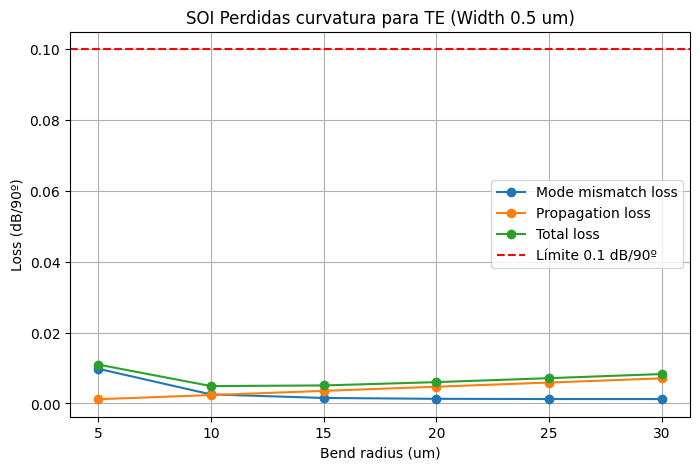

In [32]:

radios = np.array([5, 10, 15, 20, 25, 30])

# Guía de onda par TE
bend_te = gt.modes.Waveguide(
    wavelength=1550 * nm, 
    core_width=0.5,       
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.3,
    grid_resolution=50, 
)

# Mismatch Loss
mismatch_loss = gt.modes.sweep_bend_mismatch(bend_te, radios)
mismatch_loss_dB = -10 * np.log10(mismatch_loss) 

# Propagation Loss
dB_cm = 1.5 
length_cm = 0.5 * np.pi * radios * 1e-4
prop_loss_dB = dB_cm * length_cm

# Pérdida Total
total_loss_dB = mismatch_loss_dB + prop_loss_dB

# Imprimir resultados para ver cuál es menor a 0.1 dB/90
print("SOI Resultados para Width = 1.0 um a 1.55 um:")
for i in range(len(radios)):
    r = radios[i]
    m_loss = mismatch_loss_dB[i]
    p_loss = prop_loss_dB[i]
    t_loss = total_loss_dB[i]
    
    print(f"R={r} um | Mismatch: {m_loss} dB | Prop: {p_loss} dB | TOTAL: {t_loss} dB/90º")

# Graficar para pegar en la diapo
plt.figure(figsize=(8,5))
plt.title("SOI Perdidas curvatura para TE (Width 0.5 um)")
plt.plot(radios, mismatch_loss_dB, "o-", label="Mode mismatch loss")
plt.plot(radios, prop_loss_dB, "o-", label="Propagation loss")
plt.plot(radios, total_loss_dB, "o-", label="Total loss")
plt.axhline(y=0.1, color='r', linestyle='--', label="Límite 0.1 dB/90º")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB/90º)")
plt.legend()
plt.grid(True)
plt.show()

  0%|          | 0/6 [00:00<?, ?it/s]

/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

11:04:08 CET WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/mjulben/pic-upv-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/deri

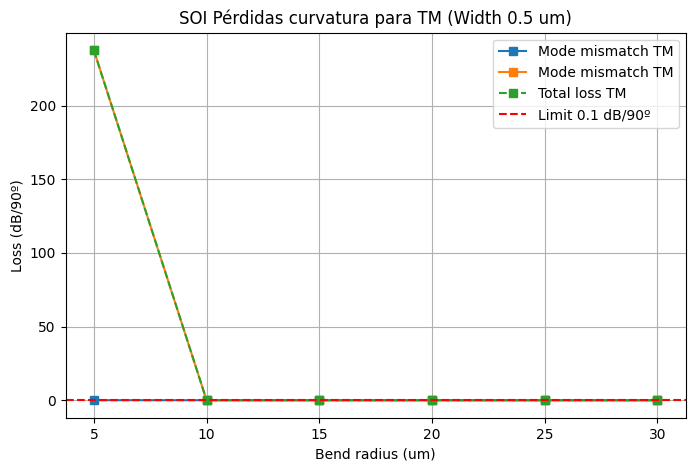

In [31]:
radios = np.array([5, 10, 15, 20, 25, 30])

bend_tm = gt.modes.Waveguide(
    wavelength=1550 * nm, 
    core_width=0.5,       
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=2,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
)

mismatch_TM = gt.modes.sweep_bend_mismatch(bend_tm, radios)
mismatch_TM_dB = -10 * np.log10(mismatch_TM)

dB_cm = 1.5
length_cm = 0.5 * np.pi * radios * 1e-4
prop_loss_dB = dB_cm * length_cm

total_loss_TM = mismatch_TM_dB[:, 1] + prop_loss_dB

plt.figure(figsize=(8,5))
plt.title("SOI Pérdidas curvatura para TM (Width 0.5 um)")
plt.plot(radios, mismatch_TM_dB, "s-", label="Mode mismatch TM")
plt.plot(radios, total_loss_TM, "s--", label="Total loss TM")
plt.axhline(y=0.1, color='r', linestyle='--', label="Limit 0.1 dB/90º")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB/90º)")
plt.legend()
plt.grid(True)
plt.show()

## Grading

LO.1. 2 Point <br> 
LO.2. 1 Points <br> 
LO.3. 3 Point <br> 
LO.4. 1 Points <br> 
**Total 7 Points** <br>
Extra (Up to) 3 Points
